<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #1e3a8a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Tratamiento de Valores Faltantes (Missing Values) ❓
      </h1>
      <p style="margin: 6px 0 0 0; color: #1e3a8a; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Programación para Ciencia de Datos
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #1e3a8a; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 05
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #2563eb; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>


---
## Introducción a los Missing Values

En este cuaderno abordaremos uno de los problemas más comunes en el análisis de datos del mundo real: los **Valores Faltantes (Missing Values)**.

Los valores faltantes ocurren cuando no hay información almacenada para una variable en una observación concreta. En Python y Pandas, generalmente se representan como `NaN` (Not a Number) o `None`. 

Ignorarlos o tratarlos de manera incorrecta puede provocar fallos al entrenar modelos de Inteligencia Artificial, e introducir sesgos severos en nuestros análisis estadísticos. Aquí aprenderemos a diagnosticarlos y utilizar diversas estrategias (desde simples eliminaciones hasta complejas imputaciones con Machine Learning) para resolverlos de la mejor manera posible.

---
### 1. Configuración del Entorno 🛠️

Lo primero que necesitamos hacer es cargar las librerías necesarias. Además de Pandas y Numpy, comenzaremos a utilizar `scikit-learn` para transformaciones avanzadas.

In [1]:
# Verificación segura de fuzzywuzzy
try:
    import fuzzywuzzy
    from fuzzywuzzy import process
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "fuzzywuzzy", "python-Levenshtein"])
    import fuzzywuzzy
    from fuzzywuzzy import process


In [2]:
# Verificación segura de fuzzywuzzy
try:
    import fuzzywuzzy
    from fuzzywuzzy import process
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "fuzzywuzzy", "python-Levenshtein"])
    import fuzzywuzzy
    from fuzzywuzzy import process


> ⚠️ *Nota: Si te encuentras con un error de `ModuleNotFoundError` en un entorno local, puedes instalar paquetes faltantes usando: `!pip install scikit-learn fuzzywuzzy` en una celda de código.*

---
### 2. Nuestro primer vistazo a los datos 🔍

Para la demostración, utilizaremos el **[Dataset de Hepatitis](https://datahub.io/machine-learning/hepatitis#readme)**. 
Este dataset contiene apariciones de hepatitis en personas. Cada entrada (fila) consta de información de salud de un paciente y si logró sobrevivir a la enfermedad (columna `class`).

In [3]:
import os
import urllib.parse
import urllib.request
import pandas as pd

# 🚀 Función de utilidad para cargar datasets de forma segura (Local o Google Colab)
def load_dataset(filename, module_name="05 - Data Preparation"):
    candidates = [
        f"data/{filename}",
        f"{module_name}/data/{filename}",
        filename
    ]
    for path in candidates:
        if os.path.exists(path):
            return path
            
    os.makedirs("data", exist_ok=True)
    target_path = f"data/{filename}"
    encoded_module = urllib.parse.quote(module_name)
    encoded_file = urllib.parse.quote(filename)
    url_main = f"https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/{encoded_module}/data/{encoded_file}"
    url_master = f"https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/master/{encoded_module}/data/{encoded_file}"
    
    print(f"📥 Descargando dataset '{filename}' desde el repositorio oficial...")
    try:
        urllib.request.urlretrieve(url_main, target_path)
    except Exception:
        urllib.request.urlretrieve(url_master, target_path)
    print(f"✅ Dataset '{filename}' cargado exitosamente.")
    return target_path

# Carga del dataset Hepatitis con valores faltantes
file_path = load_dataset('hepatitis.csv', '05 - Data Preparation')
df = pd.read_csv(file_path)
print(f'Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head()


,age,sex,steroid,antivirals,fatigue,malaise,...,alk_phosphate,sgot,albumin,protime,histology,class
0,30,male,False,False,False,False,...,85.0,18.0,4.0,NaN,False,live
1,50,female,False,False,True,False,...,135.0,42.0,3.5,NaN,False,live
2,78,female,True,False,True,False,...,96.0,32.0,4.0,NaN,False,live
3,31,female,NaN,True,False,False,...,46.0,52.0,4.0,80.0,False,live
4,34,female,True,False,False,False,...,NaN,200.0,4.0,NaN,False,live


¡Puedo ver un puñado de datos faltantes de inmediato! Están representados como `NaN` (Not a Number).

#### ¿Cuántos datos nos faltan?
Veamos qué porcentaje del conjunto de datos está en blanco para darnos una mejor idea de la escala del problema.

In [4]:
# Cantidad de valores faltantes por columna
missing_values_count = hepatitis.isnull().sum()
missing_values_count[0:10]

,0
age,0
sex,0
steroid,1
antivirals,0
fatigue,1
malaise,1
anorexia,1
liver_big,10
liver_firm,11
spleen_palpable,5


In [5]:
# ¿Cuántos valores faltantes tenemos en TOTAL?
total_cells = np.prod(hepatitis.shape)
total_missing = missing_values_count.sum()

# Porcentaje de los datos totales que se han perdido
percent_missing = (total_missing / total_cells) * 100
print(f"Porcentaje de datos faltantes en el dataset: {percent_missing:.2f}%")

Porcentaje de datos faltantes en el dataset: 5.39%


---
### 3. La intuición: ¿Por qué faltan los datos? 🧠

Llegamos a la parte de la ciencia de datos conocida como **"Intuición de Datos"**. Se trata de mirar realmente tu dataset y tratar de descubrir *por qué* es de la forma que es y cómo eso afectará tu análisis. Puede ser una parte frustrante de la ciencia de datos, especialmente si eres nuevo en el campo y no tienes mucha experiencia. Para lidiar con los valores faltantes, deberás usar tu intuición para descubrir por qué falta el valor. Una de las preguntas más importantes que puedes hacerte para ayudar a descubrir esto es esta:

> **¿Falta este valor porque no se registró o porque no existe?**

Si falta un valor porque no existe (como la altura del hijo mayor de alguien que no tiene hijos), entonces no tiene sentido intentar adivinar cuál podría ser. Es probable que desees mantener estos valores como `NaN`. Por otro lado, si falta un valor porque no se registró, entonces puedes intentar adivinar cuál podría haber sido en función de los otros valores en esa columna y fila. ¡Esto se llama imputación y aprenderemos a hacerlo a continuación! :)

Trabajemos en un ejemplo. Mirando nuestro marco de datos de `hepatitis`, es razonable pensar que los valores faltantes lo son porque no se registraron. De hecho, las características se refieren a información de salud que cada persona tiene. Si estás haciendo un análisis de datos muy cuidadoso, este es el punto en el que analizarías cada columna individualmente para descubrir la mejor estrategia para completar esos valores faltantes. Es importante hacerlo para evitar eliminar información útil o agregar algo de ruido a tus datos.

---
### 4. Estrategias para tratar Valores Faltantes ⚔️

**1) Una opción simple: Eliminar columnas (o filas) con valores faltantes**
La opción más simple es eliminar columnas (o filas) con valores faltantes. A menos que falten la mayoría de los valores en las columnas eliminadas, el modelo pierde el acceso a mucha información (¡potencialmente útil!) con este enfoque. Como ejemplo extremo, considera un conjunto de datos con 10,000 filas, donde a una columna importante le falta una sola entrada. ¡Este enfoque eliminaría la columna por completo!
Además, si eliminas cada fila que contiene un valor faltante, podrías terminar eliminando todo el conjunto de datos si cada fila en el conjunto de datos tiene al menos un valor faltante.
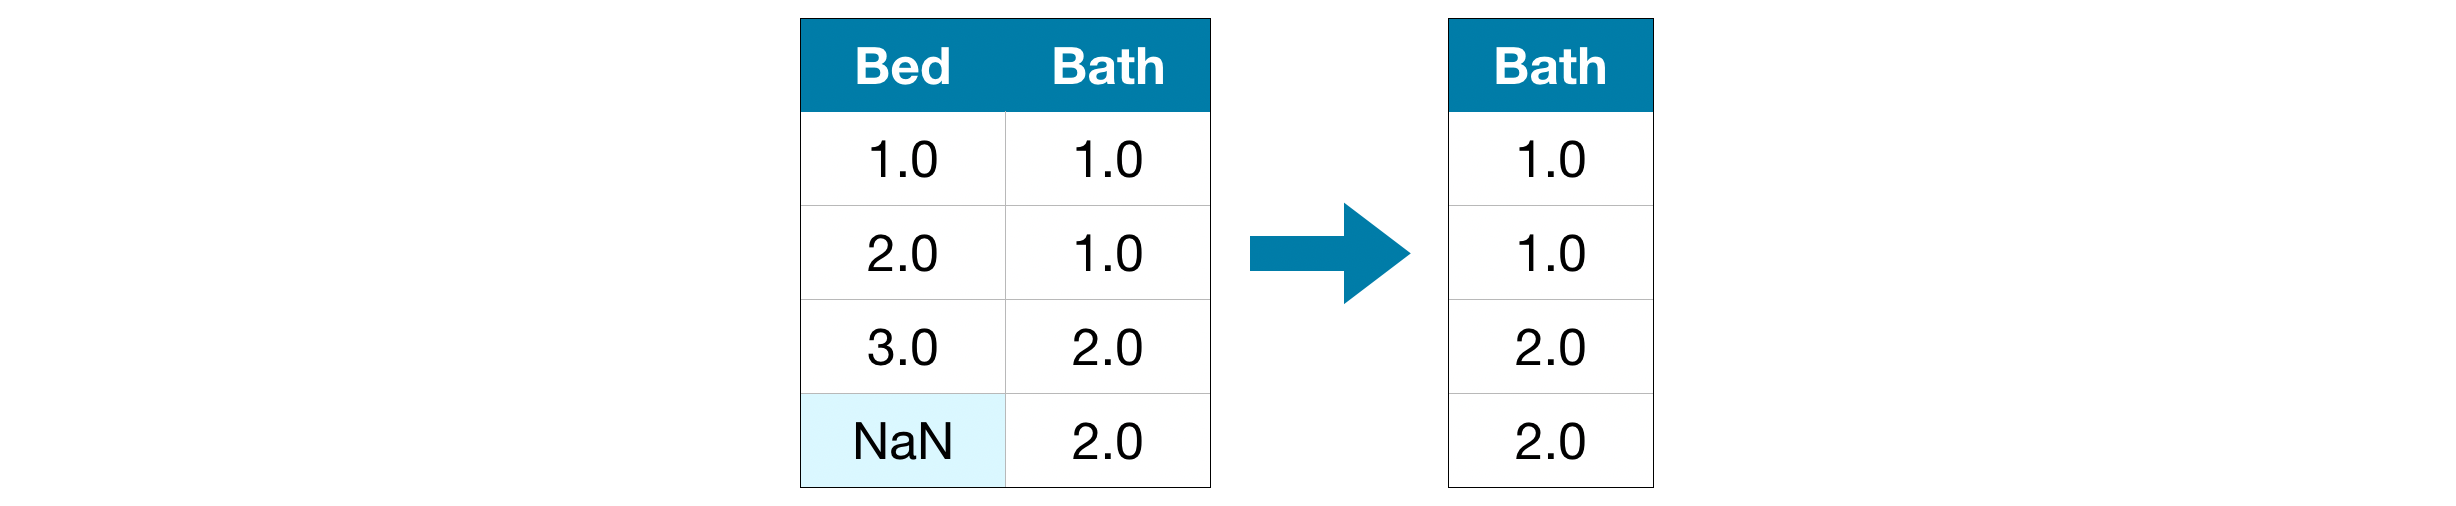

**2) Una mejor opción: Imputación**
La imputación completa los valores faltantes con algún número. Por ejemplo, podemos completar con el valor medio a lo largo de cada columna. El valor imputado no será exactamente correcto en la mayoría de los casos, pero generalmente conduce a modelos más precisos de lo que se obtendría al eliminar la columna por completo.
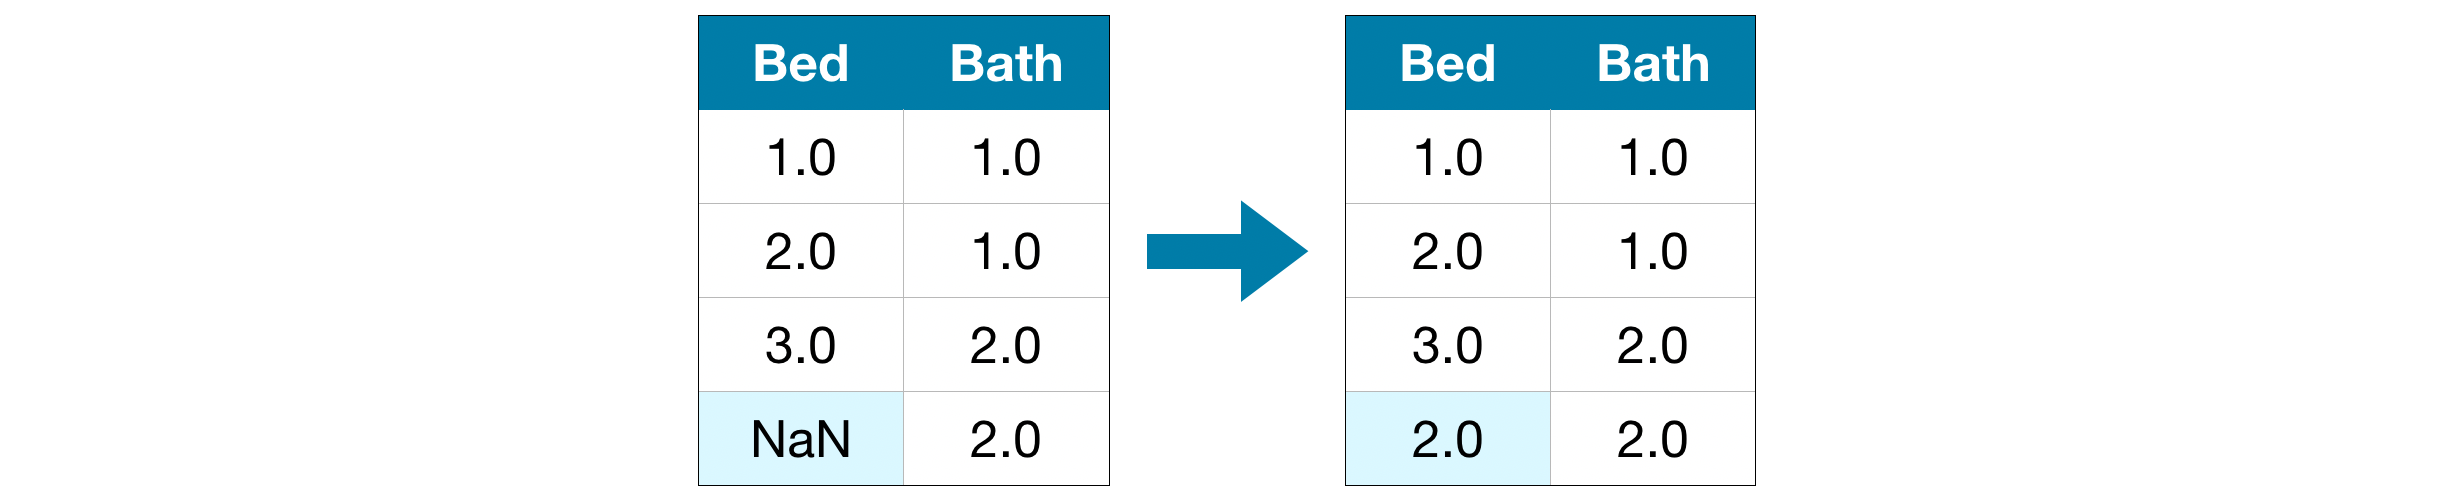

**3) Missing Indicators: Una extensión a la imputación**
La imputación es el enfoque estándar y generalmente funciona bien. Sin embargo, los valores imputados pueden estar sistemáticamente por encima o por debajo de sus valores reales (que no se recopilaron en el conjunto de datos). O las filas con valores faltantes pueden ser únicas de alguna otra manera. En ese caso, tu modelo haría mejores predicciones al considerar qué valores faltaban originalmente.
En este enfoque, imputamos los valores faltantes, como antes. Y, adicionalmente, por cada columna con entradas faltantes en el conjunto de datos original, agregamos una nueva columna que muestra la ubicación de las entradas imputadas. En algunos casos, esto mejorará significativamente los resultados. En otros, no ayuda en absoluto.
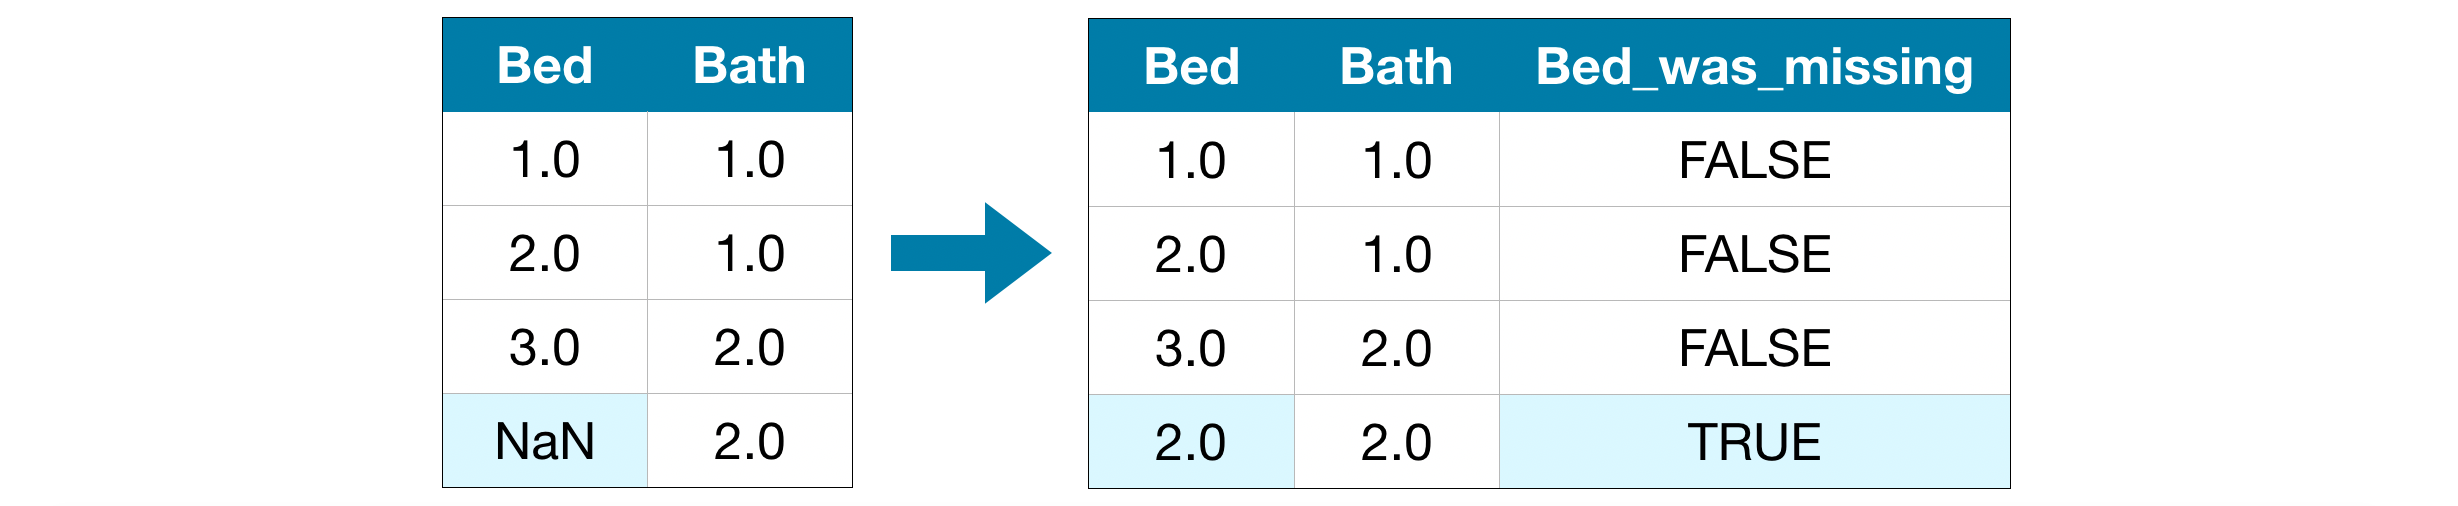



---
#### 4.1. Eliminar valores faltantes (Drop missing values)

Si tienes prisa o no tienes una razón para descubrir por qué faltan tus valores, una opción que tienes es simplemente eliminar las filas o columnas que contienen valores faltantes. (Nota: ¡Generalmente no recomiendo este enfoque para proyectos importantes! Por lo general, vale la pena tomarse el tiempo para revisar sus datos y analizar realmente todas las columnas con valores faltantes una por una para conocer realmente su conjunto de datos).

Si estás seguro de que quieres eliminar filas con valores faltantes, pandas tiene una función útil, `dropna()`, para ayudarte a hacer esto. ¡Probémoslo en nuestro conjunto de datos de hepatitis!

In [6]:
print(f"Total de filas antes de eliminar: {hepatitis.shape[0]}")

# Eliminamos todas las filas que contienen al menos un valor faltante
hepatitis_clean = hepatitis.dropna()
print(f"Total de filas después de eliminar nulos: {hepatitis_clean.shape[0]}")

Total de filas antes de eliminar: 155
Total de filas después de eliminar nulos: 80


¡Perdimos casi la mitad de los pacientes! ¿Qué pasa si eliminamos las *columnas* con nulos en lugar de las *filas*?

In [7]:
# Eliminamos todas las columnas con al menos un valor faltante (axis=1)
columns_with_na_dropped = hepatitis.dropna(axis=1)

print(f"Columnas originales: {hepatitis.shape[1]}")
print(f"Columnas sobrevivientes: {columns_with_na_dropped.shape[1]}")
display(columns_with_na_dropped.head(3))

Columnas originales: 20
Columnas sobrevivientes: 5
   age     sex  antivirals  histology class
0   30    male       False      False  live
1   50  female       False      False  live
2   78  female       False      False  live


¡Hemos perdido bastantes datos! Así que deberíamos probar otro enfoque.


---
##### 🛠️ Práctica 1: Eliminando Nulos


Usando el dataframe `hepatitis`, crea una copia llamada `hep_drop` y elimina todas las **columnas** que tengan al menos un valor nulo. Imprime cuántas columnas quedaron.

In [ ]:
# Escribe tu código aquí



<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
hep_drop = hepatitis.dropna(axis=1)
print("Columnas restantes:", hep_drop.shape[1])
```
</details>


---
#### 4.2. Imputación (Imputation)

Otra opción es intentar completar los valores faltantes. Algunas estrategias tienen sentido solo con valores numéricos, como reemplazar el valor faltante con el valor promedio de la columna, mientras que otras estrategias también se pueden usar para valores categóricos (como reemplazar el valor faltante con el valor más frecuente de la columna).

Para reemplazar los valores faltantes, podemos usar las funciones de pandas o scikit-learn. Veremos las funciones de scikit-learn más adelante. Se pueden usar tres funciones de pandas: `fillna()`, `replace()` e `interpolate()`. La función `fillna()` reemplaza todos los valores NaN con el valor pasado como argumento.



##### Imputación de Valor Constante
Una opción que tenemos es reemplazar los valores faltantes con una constante predefinida.

In [8]:
# Reemplazamos todos los NA con el valor que viene justo DESPUÉS (bfill)
# Y si la última fila queda vacía, rellenamos el restante con 0.
hepatitis.bfill(axis=0).fillna(0).head()

,age,sex,steroid,antivirals,fatigue,malaise,...,alk_phosphate,sgot,albumin,protime,histology,class
0,30,male,False,False,False,False,...,85.0,18.0,4.0,80.0,False,live
1,50,female,False,False,True,False,...,135.0,42.0,3.5,80.0,False,live
2,78,female,True,False,True,False,...,96.0,32.0,4.0,80.0,False,live
3,31,female,True,True,False,False,...,46.0,52.0,4.0,80.0,False,live
4,34,female,True,False,False,False,...,95.0,200.0,4.0,75.0,False,live


##### Rellenando valores numéricos
Seleccionamos columnas numéricas para aplicar un método de relleno específico. Luego, rellenamos los valores NaN de las columnas numéricas con el valor promedio, dado por la función `df.mean()`.

In [9]:
# 1. Seleccionamos solo las columnas numéricas
numeric = hepatitis.select_dtypes(include=np.number)
numeric_columns = numeric.columns

# Rellenamos los nulos numéricos con la media aritmética de cada columna
hepatitis[numeric_columns] = hepatitis[numeric_columns].fillna(hepatitis[numeric_columns].mean())

# 2. Seleccionamos columnas de tipo object (categorías) y Booleanas, excluyendo el 'target' (class)
cat_columns = hepatitis.select_dtypes(include=['object', 'bool']).columns.tolist()
cat_columns.remove('class')

# Rellenamos los nulos categóricos con la Moda (el valor más común)
hepatitis[cat_columns] = hepatitis[cat_columns].fillna(hepatitis[cat_columns].mode().iloc[0])

print("Porcentaje de nulos actual:")
print((hepatitis.isna().sum() / len(hepatitis)) * 100)

Porcentaje de nulos actual:
age          0.0
sex          0.0
steroid      0.0
            ... 
protime      0.0
histology    0.0
class        0.0
Length: 20, dtype: float64


---
###### 🛠️ Práctica 2: Imputación


Tienes un pequeño dataset con la presión sanguínea de pacientes: `presion = pd.Series([120, np.nan, 130, 125, np.nan])`.
Usa Pandas para rellenar los valores nulos con la media aritmética de la serie y muestra el resultado.

In [ ]:
# Escribe tu código aquí



<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
presion = pd.Series([120, np.nan, 130, 125, np.nan])
presion_rellenada = presion.fillna(presion.mean())
print(presion_rellenada)
```
</details>


##### Interpolación
Otra solución para reemplazar los valores faltantes implica el uso de otras funciones, como la interpolación lineal. En este caso, por ejemplo, podríamos reemplazar un valor faltante sobre una columna, con la interpolación entre el anterior y el siguiente. Esto se puede lograr mediante el uso de la función `interpolate()`.

In [10]:
# Recargamos datos originales para demostrar la interpolación
hepatitis_raw = pd.read_csv(file_path)

# Aplicamos interpolación lineal sobre las numéricas
hepatitis_raw[numeric_columns] = hepatitis_raw[numeric_columns].interpolate(method='linear', limit_direction='forward')
hepatitis_raw[numeric_columns].head(10)

,age,bilirubin,alk_phosphate,sgot,albumin,protime
0,30,1.00,85.0,18.000000,4.000000,NaN
1,50,0.90,135.0,42.000000,3.500000,NaN
2,78,0.70,96.0,32.000000,4.000000,NaN
3,31,0.70,46.0,52.000000,4.000000,80.0
4,34,1.00,70.5,200.000000,4.000000,77.5
5,34,0.90,95.0,28.000000,4.000000,75.0
6,51,0.95,91.6,34.666667,4.133333,77.0
7,23,1.00,88.2,41.333333,4.266667,79.0
8,39,0.70,84.8,48.000000,4.400000,81.0
9,30,1.00,81.4,120.000000,3.900000,83.0


---
### 5.  Imputación con scikit-learn 🧗
 
La biblioteca scikit-learn proporciona tres mecanismos para lidiar con los valores faltantes:
- Imputación de características univariadas
- Imputación de características multivariadas
- Imputación de vecinos más cercanos



#### Imputación de características univariadas
La imputación de características univariadas implica el reemplazo de valores faltantes con un valor constante o algunas estadísticas proporcionadas relacionadas con una característica. La clase `SimpleImputer` se puede utilizar para realizar esta imputación. El parámetro `strategy` acepta los valores: "mean", "median", "most_frequent", "constant".



#### Imputación de características multivariadas
En la imputación de características multivariadas, cada característica con valores faltantes se calcula en función de las otras características. Se construye una imputación iterativa, por lo que se debe especificar el número máximo de iteraciones. Podemos usar la clase `IterativeImputer`.

In [11]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Recargamos nuevamente para tener los NaN limpios
hep = pd.read_csv(file_path)

preprocessor_iter = IterativeImputer(max_iter=10, random_state=0)

# Aislamos las dos características que queremos cruzar para predecir nulos
X1 = np.array(hep['liver_big']).reshape(-1, 1)
X2 = np.array(hep['fatigue']).reshape(-1, 1)
X_combined = np.hstack((X1, X2))

# Entrenamos el imputador y transformamos los datos rellenando los huecos iterativamente
X_prep = preprocessor_iter.fit_transform(X_combined)

# Devolvemos el resultado al dataframe original (recuperando solo liver_big que es la columna 0)
hep['liver_big_multivariate'] = np.hsplit(X_prep, 2)[0].reshape(1, -1)[0]
hep['liver_big_multivariate'] = hep['liver_big_multivariate'].astype(bool)

hep[['liver_big', 'liver_big_multivariate', 'fatigue']].head(5)

,liver_big,liver_big_multivariate,fatigue
0,False,False,False
1,False,False,True
2,True,True,True
3,True,True,False
4,True,True,False


#### Imputación por Vecinos Más Cercanos
Esta categoría de imputación completa los valores faltantes utilizando el enfoque de k vecinos más cercanos (k-Nearest Neighbors). Cada valor faltante se calcula utilizando los valores de los `n_neighbors` vecinos más cercanos que tienen un valor. Podemos usar la clase `KNNImputer` de la biblioteca scikit-learn.

In [12]:
from sklearn.impute import KNNImputer

# n_neighbors=5 significa que miraremos a los 5 pacientes más parecidos
preprocessor_knn = KNNImputer(n_neighbors=5, weights="distance")

# Transformamos
X_knn_prep = preprocessor_knn.fit_transform(X_combined)

hep['liver_big_knn'] = np.hsplit(X_knn_prep, 2)[0].reshape(1, -1)[0]
hep['liver_big_knn'] = hep['liver_big_knn'].astype(bool)

hep[['liver_big', 'liver_big_multivariate', 'liver_big_knn']].head(5)

,liver_big,liver_big_multivariate,liver_big_knn
0,False,False,False
1,False,False,False
2,True,True,True
3,True,True,True
4,True,True,True


---
### 6. Missing indicators 🚩

Crea variables indicadoras binarias que denotan si falta un valor o no. Esto permite que el modelo tenga en cuenta la falta como una categoría separada.

In [13]:
from sklearn.impute import SimpleImputer

hep_indic = pd.read_csv(file_path)
numeric_hep = hep_indic.select_dtypes(include=np.number)

# 1. Obtenemos los nombres de las columnas que contienen al menos un nulo
cols_with_missing = [col for col in numeric_hep.columns if numeric_hep[col].isnull().any()]

# 2. Para cada una de esas columnas, creamos una nueva columna indicadora Booleana
for col in cols_with_missing:
    numeric_hep[col + '_was_missing'] = numeric_hep[col].isnull()

# 3. Ahora SÍ realizamos la imputación clásica sobre las columnas numéricas
my_imputer = SimpleImputer()
imputed_matrix = my_imputer.fit_transform(numeric_hep)

# 4. Reconstruimos el DataFrame a partir de la matriz devuelta por Scikit-Learn
imputed_hep = pd.DataFrame(imputed_matrix, columns=numeric_hep.columns)

display(imputed_hep.head(10))

    age  bilirubin  alk_phosphate       sgot   albumin    protime  bilirubin_was_missing  alk_phosphate_was_missing  sgot_was_missing  albumin_was_missing  protime_was_missing
0  30.0   1.000000      85.000000   18.00000  4.000000  61.852273                    0.0                        0.0               0.0                  0.0                  1.0
1  50.0   0.900000     135.000000   42.00000  3.500000  61.852273                    0.0                        0.0               0.0                  0.0                  1.0
2  78.0   0.700000      96.000000   32.00000  4.000000  61.852273                    0.0                        0.0               0.0                  0.0                  1.0
3  31.0   0.700000      46.000000   52.00000  4.000000  80.000000                    0.0                        0.0               0.0                  0.0                  0.0
4  34.0   1.000000     105.325397  200.00000  4.000000  61.852273                    0.0                        1.0     

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Programación para Ciencia de Datos</i>
  </p>
</div>
